# A set of scaffolds from CheMBL papers

Been here a few times, keep refining it. :-)

Sets of compounds from lead-optimization datasets and explanations [in this blog post](https://greglandrum.github.io/rdkit-blog/posts/2026-07-16-identifying-lead-opt-docs.html).

# On to the work

## Start with the preliminaries

We need to do a bunch of imports and define some functions we'll use later.



In [1]:
import numpy
from rdkit.Chem.Draw import IPythonConsole
import pandas as pd
from rdkit.Chem import PandasTools
from rdkit import Chem
from rdkit.Chem import rdFMCS as MCS
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor
rdDepictor.SetPreferCoordGen(True)
import pickle
from rdkit import rdBase
print(rdBase.rdkitVersion)
%load_ext sql
%config SqlMagic.feedback = False
%config SqlMagic.named_parameters="enabled"
import time
print(time.asctime())

2026.03.3
Thu Aug 20 04:45:00 2026


In [2]:
# define a function to convert a query molecule to SVG

from IPython.display import SVG
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
def moltosvg(mol,molSize=(450,250),kekulize=True):
    mc = Chem.Mol(mol.ToBinary())
    if kekulize:
        try:
            Chem.Kekulize(mc)
        except:
            mc = Chem.Mol(mol)
    if not mc.GetNumConformers():
        rdDepictor.Compute2DCoords(mc)
    drawer = rdMolDraw2D.MolDraw2DSVG(molSize[0],molSize[1])
    # the MolDraw2D code is not very good at dealing with atom queries,
    # this is a workaround
    opts = drawer.drawOptions()
    for atom in mc.GetAtoms():
        if atom.HasQuery() and atom.DescribeQuery().find('AtomAtomicNum')!=0:
            opts.atomLabels[atom.GetIdx()]=atom.GetSmarts()
    drawer.DrawMolecule(mc)
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()
    return svg

In [3]:
# define a function to find the MCS for a set of molecules and return some summary info about that MCS

import time
# we will use a namedtuple to return the results
from collections import namedtuple
MCSRes=namedtuple('MCSRes',('smarts','numAtoms','numMols','avgNumMolAtoms','mcsTime'))

def MCS_Report(ms,printSmarts=True,
               atomCompare=MCS.AtomCompare.CompareAny,
               bondCompare=MCS.BondCompare.CompareAny,
               completeRingsOnly=True,
               **kwargs):
    t1=time.time()
    mcs = MCS.FindMCS(ms,atomCompare=atomCompare,bondCompare=bondCompare,timeout=30,completeRingsOnly=completeRingsOnly,
                      **kwargs)
    t2=time.time()
    nAts = numpy.array([x.GetNumAtoms() for x in ms])
    print('Mean nAts %.1f, mcs nAts: %d'%(nAts.mean(),mcs.numAtoms))
    if printSmarts: 
        print(mcs.smartsString)
    mcsM = Chem.MolFromSmarts(mcs.smartsString)         
    mcsM.UpdatePropertyCache(False)
    Chem.SetHybridization(mcsM)
    svg = moltosvg(mcsM,kekulize=False)
    tpl = MCSRes(mcs.smartsString,mcs.numAtoms,len(ms),nAts,t2-t1)
    return tpl,svg


## Grab the data

In [4]:
with open('./results/lead_optimization_sets.pkl','rb') as f:
    df = pickle.load(f)

df.shape

(37295, 7)

In [5]:
df.head()

,doc_id,doc_chembl_id,molregno,compound_chembl_id,compound_type,assay_count,canonical_smiles
0,37919,CHEMBL1140586,416886,CHEMBL250403,local,34,CCCN1CCO[C@H](c2cccc(O)c2)C1
1,37919,CHEMBL1140586,3854,CHEMBL53,reference,3,CN1CCc2cccc3c2[C@H]1Cc1ccc(O)c(O)c1-3
2,37919,CHEMBL1140586,19316,CHEMBL589,reference,3,CCCN(CCC)CCc1cccc2c1CC(=O)N2
3,37919,CHEMBL1140586,88815,CHEMBL301265,reference,3,CCCN[C@H]1CCc2nc(N)sc2C1
4,37919,CHEMBL1140586,259724,CHEMBL155731,local,3,CCCN1CCC[C@@H]2Cc3nc(N)ncc3C[C@H]21


In [6]:
doc_df = df[(df['doc_chembl_id']=='CHEMBL1140586') & (df['compound_type']=='local')]
doc_df.shape

(44, 7)

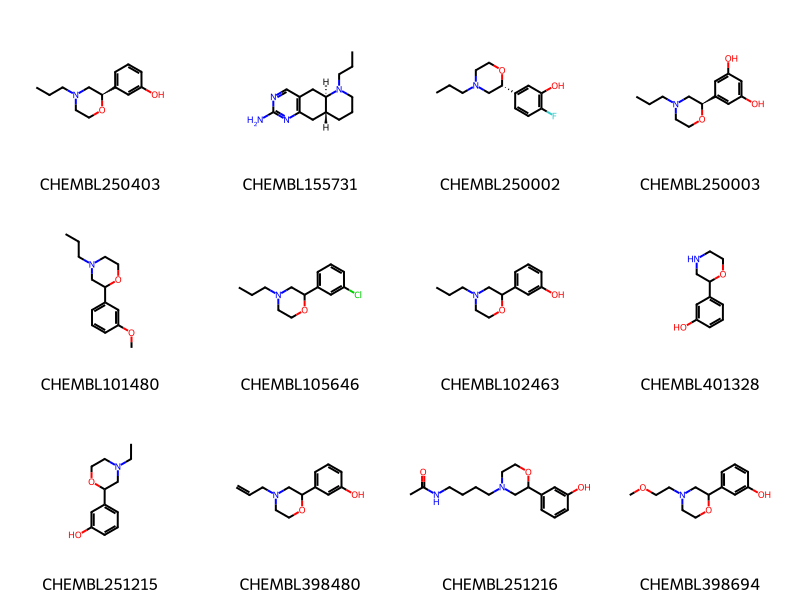

In [7]:
ms = doc_df['canonical_smiles'].apply(Chem.MolFromSmiles).to_list()
Draw.MolsToGridImage(ms[:12],molsPerRow=4,legends=doc_df['compound_chembl_id'].to_list())

Mean nAts 17.6, mcs nAts: 15
[#6]-&!@[#6]-&!@[#7]1-&@[#6]-&@[#6]-&@[#8]-&@[#6](-&@[#6]-&@1)-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@1)-&!@[#8,#6,#7,#16,#17]


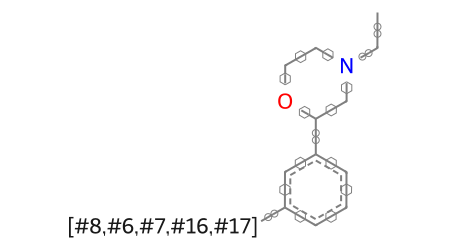

In [19]:
tpl,svg=MCS_Report(ms,threshold=0.9,completeRingsOnly=True)
SVG(svg)

Mean nAts 17.6, mcs nAts: 15
[#6]-,=;!@[#6]-&!@[#6]-&!@[#7]1-&@[#6]-&@[#6]-&@[#8]-&@[#6](-&@[#6]-&@1)-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1


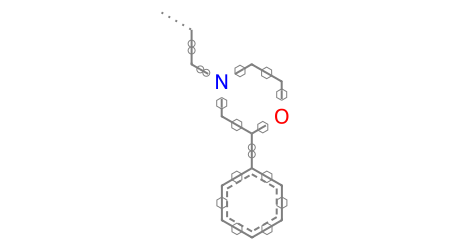

In [21]:
tpl,svg=MCS_Report(ms,threshold=0.9,completeRingsOnly=True,
        atomCompare=MCS.AtomCompare.CompareElements)
SVG(svg)

In [27]:
Chem.MolFromSmarts('[#6]-,=[#6]').GetBondWithIdx(0).DescribeQuery()

'BondOr\n  BondOrder 1 = val\n  BondOrder 2 = val\n'

In [20]:
import pickle


def run_doc(df, doc_id, threshold=0.9):
    doc_df = df[(df['doc_chembl_id'] == doc_id)
                & (df['compound_type'] == 'local')]

    ms = doc_df['canonical_smiles'].apply(Chem.MolFromSmiles).to_list()
    print(f'{len(ms)} molecules found for document {doc_id}')
    if len(ms) < 2:
        return None
    tpl, svg = MCS_Report(ms, threshold=threshold, completeRingsOnly=True)
    smis = doc_df['canonical_smiles'].to_list()
    return (doc_id, smis, tpl, svg)

In [ ]:

#results = pickle.load(open('../data/scaffolds_lead_opt.pkl','rb'))
results = []
seen = [x[0][0] for x in results if x is not None]

doc_ids = df['doc_chembl_id'].unique()
nrows = len(doc_ids)
for i,did in enumerate(doc_ids):
    print(f'Doing row {i+1} of {nrows}')
    if did in seen:
        continue
    tpl = run_doc(df,did)
    results.append(tpl)
    if not (i+1)%100:
        pickle.dump(results,open('../data/scaffolds_lead_opt.pkl','wb+'))
pickle.dump(results,open('../data/scaffolds_lead_opt.pkl','wb+'))

Doing row 1 of 770
44 molecules found for document CHEMBL1140586
Mean nAts 17.6, mcs nAts: 15
[#6]-&!@[#6]-&!@[#7]1-&@[#6]-&@[#6]-&@[#8]-&@[#6](-&@[#6]-&@1)-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@1)-&!@[#8,#6,#7,#16,#17]
Doing row 2 of 770
31 molecules found for document CHEMBL1143305
Mean nAts 32.6, mcs nAts: 18
[#6]-&!@[#7,#6]-,=;!@[#6,#7]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#6]-&!@[#7]-&!@[#6]1:&@[#7,#6]:&@[#6,#7]:&@[#6,#7]:&@[#6](:&@[#7,#6]:&@1)-&!@[#6,#7]
Doing row 3 of 770
39 molecules found for document CHEMBL1152282
Mean nAts 31.6, mcs nAts: 16
[#7,#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#7]-&!@[#6](=&!@[#8])-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#7,#6]:&@[#6]:&@1
Doing row 4 of 770
41 molecules found for document CHEMBL1153392
Mean nAts 20.1, mcs nAts: 17
[#6]-&!@[#6]1:&@[#6]:&@[#6](-&!@[#7]-&!@[#6]2:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2):&@[#7]2:&@[#6](:&@[#7]:&@1):&@[#7]:&@[#6]:&@[#7]:&@2
Doing row 5 of 770
33 molecules found for documen

In [33]:
results2 = pickle.load(open('../data/scaffolds_lead_opt.pkl', 'rb'))
len(results2)

770

In [48]:
tmp = []
for row in results:
    tmp.append((row[0],row[2].smarts,str(row[2].numAtoms/row[2].avgNumMolAtoms.mean())))
with open('../data/scaffolds_lead_opt.txt','w+') as outf:
    print('doc_chembl_id\tsmarts\tfraction_of_average_molecule_size',file=outf)
    for row in tmp:
        print('\t'.join(row),file=outf)

In [35]:
len(results)

770

Repeat, but use the atom types (elements) in the MCS:

In [22]:
import pickle


def run_doc2(df, doc_id, threshold=0.9):
    doc_df = df[(df['doc_chembl_id'] == doc_id)
                & (df['compound_type'] == 'local')]

    ms = doc_df['canonical_smiles'].apply(Chem.MolFromSmiles).to_list()
    print(f'{len(ms)} molecules found for document {doc_id}')
    if len(ms) < 2:
        return None
    tpl, svg = MCS_Report(ms,
                          threshold=threshold,
                          completeRingsOnly=True,
                          atomCompare=MCS.AtomCompare.CompareElements)
    smis = doc_df['canonical_smiles'].to_list()
    return (doc_id, smis, tpl, svg)


In [ ]:
results2 = []
seen = [x[0] for x in results2 if x is not None]

doc_ids = df['doc_chembl_id'].unique()
nrows = len(doc_ids)
for i,did in enumerate(doc_ids):
    print(f'Doing row {i+1} of {nrows}')
    if did in seen:
        continue
    tpl = run_doc2(df,did)
    results2.append(tpl)
    if not (i+1)%100:
      pickle.dump(results2,open('../data/scaffolds_lead_opt_specific.pkl','wb+'))
pickle.dump(results2,open('../data/scaffolds_lead_opt_specific.pkl','wb+'))



Doing row 1 of 770
44 molecules found for document CHEMBL1140586
Mean nAts 17.6, mcs nAts: 15
[#6]-,=;!@[#6]-&!@[#6]-&!@[#7]1-&@[#6]-&@[#6]-&@[#8]-&@[#6](-&@[#6]-&@1)-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1
Doing row 2 of 770
31 molecules found for document CHEMBL1143305
Mean nAts 32.6, mcs nAts: 16
[#7]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#7]-&!@[#6](=&!@[#8])-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1
Doing row 3 of 770
39 molecules found for document CHEMBL1152282
Mean nAts 31.6, mcs nAts: 16
[#7]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#7]-&!@[#6](=&!@[#8])-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#7]:&@[#6]:&@1
Doing row 4 of 770
41 molecules found for document CHEMBL1153392
Mean nAts 20.1, mcs nAts: 17
[#6]-&!@[#6]1:&@[#6]:&@[#6](-&!@[#7]-&!@[#6]2:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2):&@[#7]2:&@[#6](:&@[#7]:&@1):&@[#7]:&@[#6]:&@[#7]:&@2
Doing row 5 of 770
33 molecules found for document CHEMBL1136951
Mean nAts 29.8, mcs nAts: 6
[#6]-&!@[#6]1:,-;

In [36]:
tmp = []
for row in results2:
    tmp.append((row[0], row[2].smarts,
                str(row[2].numAtoms / row[2].avgNumMolAtoms.mean())))
with open('../data/scaffolds_lead_opt_specific.txt', 'w+') as outf:
    print('doc_chembl_id\tsmarts\tfraction_of_average_molecule_size',
          file=outf)
    for row in tmp:
        print('\t'.join(row), file=outf)

# Look at some results

The data is organized in a dictionary with one entry per paper.

The `MCS_Report()` function defined above prints out the mean number of atoms per molecule in the input along with the size of the MCS. This is intended to help assess whether or not the MCS is actually a scaffold.

How many "scaffolds" do we have in total?

In [7]:
import pickle
results = pickle.load(open('../data/scaffolds_lead_opt.pkl', 'rb'))
results2 = pickle.load(open('../data/scaffolds_lead_opt_specific.pkl', 'rb'))

In [8]:
len(results),len(results2)

(770, 770)

In [9]:
results[0][0]

'CHEMBL1140586'

In [10]:
tbl = []
for row in results:
    doc_id,smis,tpl,svg = row
    m = Chem.MolFromSmarts(tpl.smarts)
    m.UpdatePropertyCache(False)
    rdDepictor.Compute2DCoords(m)
    tbl.append((doc_id,tpl.numAtoms,tpl.avgNumMolAtoms.mean(),tpl.smarts,tpl.mcsTime))
scaff_df = pd.DataFrame(data=tbl,columns=('doc_chembl_id','numAtoms','avgNumMolAtoms','smarts','time'))

tbl2 = []
for row in results2:
    doc_id,smis,tpl,svg = row
    m = Chem.MolFromSmarts(tpl.smarts)
    m.UpdatePropertyCache(False)
    rdDepictor.Compute2DCoords(m)
    tbl2.append((doc_id,tpl.numAtoms,tpl.avgNumMolAtoms.mean(),tpl.smarts,tpl.mcsTime))
scaff_df2 = pd.DataFrame(data=tbl2,columns=('doc_chembl_id','numAtoms','avgNumMolAtoms','smarts','time'))
scaff_df2.head(5)

,doc_chembl_id,numAtoms,avgNumMolAtoms,smarts,time
0,CHEMBL1140586,15,17.590909,"[#6]-,=;!@[#6]-&!@[#6]-&!@[#7]1-&@[#6]-&@[#6]-...",0.004567
1,CHEMBL1143305,16,32.612903,[#7]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#...,0.290015
2,CHEMBL1152282,16,31.641026,[#7]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#...,0.008485
3,CHEMBL1153392,17,20.146341,[#6]-&!@[#6]1:&@[#6]:&@[#6](-&!@[#7]-&!@[#6]2:...,0.033392
4,CHEMBL1136951,6,29.787879,"[#6]-&!@[#6]1:,-;@[#6]:,-;@[#6]:,-;@[#6]:,-;@[...",0.015072


In [11]:
len(scaff_df), len(scaff_df2)

(770, 770)

How many are reasonably sized?

In [12]:
len(scaff_df[scaff_df.numAtoms > 6]), len(scaff_df2[scaff_df2.numAtoms > 6])

(764, 735)

How many make up a large percentage of the average molecule size?

In [13]:
len(scaff_df[scaff_df.numAtoms / scaff_df.avgNumMolAtoms > 0.6]), len(
    scaff_df2[scaff_df2.numAtoms / scaff_df2.avgNumMolAtoms > 0.6])

(471, 285)

Not bad! It's still worth looking at the ones that are super small:

In [14]:
scaff_df[scaff_df.numAtoms <= 6].head()

,doc_chembl_id,numAtoms,avgNumMolAtoms,smarts,time
159,CHEMBL4196006,6,15.809524,[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1,0.007589
187,CHEMBL4342498,2,33.600000,"[#8,#6]=,-;!@[#6,#7,#8]",30.139387
222,CHEMBL4402562,4,20.441176,"[#8,#6,#7]=,-;!@[#6,#16](-,=;!@[#8,#6,#7])-,=;...",0.001956
663,CHEMBL6087400,6,17.228070,"[#6]1:,-;@[#6]:,-;@[#6]:,-;@[#6]:,-;@[#6]:,-;@...",0.036301
700,CHEMBL6103656,6,17.742857,"[#6]1:,-;@[#6]-,:;@[#6,#7]-,:;@[#6,#7]-,:;@[#7...",0.284387


In [15]:
scaff_df2[scaff_df2.numAtoms <= 6].head()

,doc_chembl_id,numAtoms,avgNumMolAtoms,smarts,time
4,CHEMBL1136951,6,29.787879,"[#6]-&!@[#6]1:,-;@[#6]:,-;@[#6]:,-;@[#6]:,-;@[...",0.015072
27,CHEMBL2034824,2,36.095238,[#6]-&!@[#6],30.271687
54,CHEMBL3352559,6,23.371429,[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1,0.005176
86,CHEMBL3785091,3,28.728395,"[#8]=,-;!@[#6]-&!@[#6]",0.013217
106,CHEMBL4011608,6,18.257143,[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1,0.006619


Look at compounds from one of those assays:

There are 35 molecules for this document


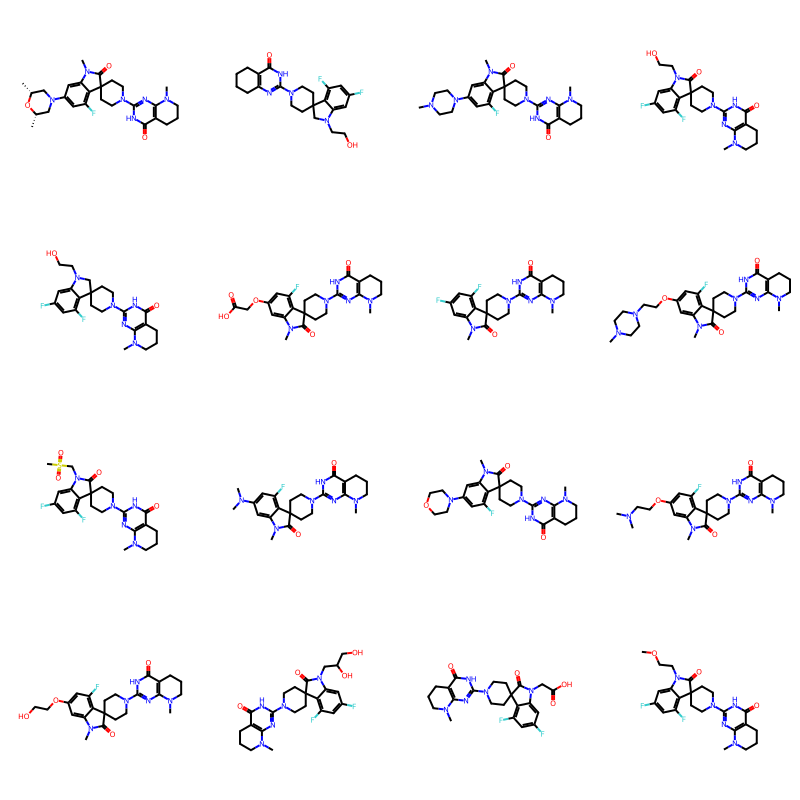

In [16]:
a = [x for x in results2 if x[0]=='CHEMBL4342498'][0]
print(f'There are {len(a[1])} molecules for this document')
mols = [Chem.MolFromSmiles(y) for y in a[1]]
Draw.MolsToGridImage(mols[:16],molsPerRow=4)

There is clearly a scaffold there, it just doesn't cover 90% of the molecules.

In [17]:
len([x for x in mols if x.HasSubstructMatch(Chem.MolFromSmarts('C1C(=O)Nc2ccccc12'))]),0.9*len(mols)

(30, 31.5)

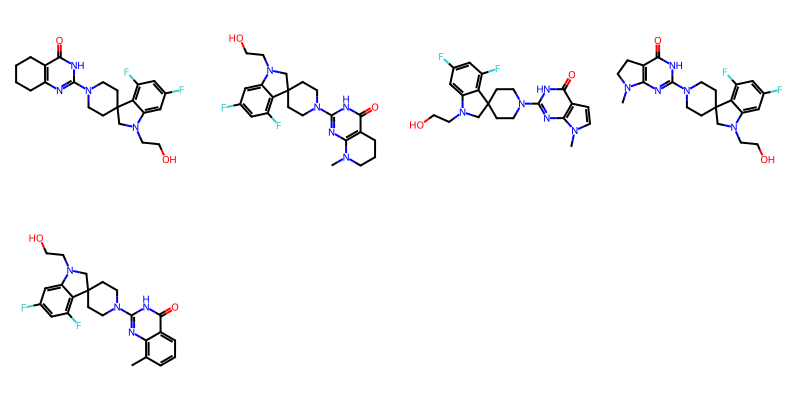

In [18]:
Draw.MolsToGridImage([x for x in mols if not x.HasSubstructMatch(Chem.MolFromSmarts('C1C(=O)Nc2ccccc12'))],molsPerRow=4)

In [21]:

tpl = run_doc(df, 'CHEMBL4342498', threshold=0.8)


35 molecules found for document CHEMBL4342498
Mean nAts 33.6, mcs nAts: 28
[#8]=&!@[#6]1:&@[#7]:&@[#6](-&!@[#7]2-&@[#6]-&@[#6]-&@[#6]3(-&@[#6]-&@[#6]-&@2)-&@[#6]-&@[#7](-&@[#6]2:&@[#6]-&@3:&@[#6](:&@[#6]:&@[#6](:&@[#6]:&@2)-&!@[#9,#7,#8])-&!@[#9])-&!@[#6]):&@[#7]:&@[#6]2:&@[#6]:&@1-,:;@[#6]-,:;@[#6]-,:;@[#6]-,:;@[#6,#7]-,:;@2


In [23]:
tpl2 = run_doc2(df, 'CHEMBL4342498', threshold=0.85)

35 molecules found for document CHEMBL4342498
Mean nAts 33.6, mcs nAts: 23
[#8]=&!@[#6]1:&@[#7]:&@[#6](-&!@[#7]2-&@[#6]-&@[#6]-&@[#6]3(-&@[#6]-&@[#6]-&@2)-&@[#6]-&@[#7](-&@[#6]2:&@[#6]-&@3:&@[#6](:&@[#6]:&@[#6]:&@[#6]:&@2)-&!@[#9])-&!@[#6]):&@[#7]:&@[#6]:&@[#6]:&@1


In [45]:
scaff_df2.head()

,doc_chembl_id,numAtoms,avgNumMolAtoms,smarts,time
0,CHEMBL1140586,15,17.590909,"[#6]-,=;!@[#6]-&!@[#6]-&!@[#7]1-&@[#6]-&@[#6]-...",0.004567
1,CHEMBL1143305,16,32.612903,[#7]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#...,0.290015
2,CHEMBL1152282,16,31.641026,[#7]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#...,0.008485
3,CHEMBL1153392,17,20.146341,[#6]-&!@[#6]1:&@[#6]:&@[#6](-&!@[#7]-&!@[#6]2:...,0.033392
4,CHEMBL1136951,6,29.787879,"[#6]-&!@[#6]1:,-;@[#6]:,-;@[#6]:,-;@[#6]:,-;@[...",0.015072


In [25]:
relaxed_results2 = []

scaff_df2['scaff_frac'] = scaff_df2.numAtoms / scaff_df2.avgNumMolAtoms

to_expand = scaff_df2[scaff_df2.scaff_frac < 0.6]

doc_ids = to_expand.doc_chembl_id.unique().tolist()
nrows = len(doc_ids)
for i, did in enumerate(doc_ids):
    print(f'Doing row {i+1} of {nrows}')
    tpl = run_doc2(df, did, threshold=0.8)
    relaxed_results2.append(tpl)

pickle.dump(relaxed_results2, open('../data/scaffolds_lead_opt_specific_relaxed.pkl', 'wb+'))

Doing row 1 of 484
31 molecules found for document CHEMBL1143305
Mean nAts 32.6, mcs nAts: 19
[#7]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#7]-&!@[#6](=&!@[#8])-&!@[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#6]-&!@[#7]-&!@[#6]
Doing row 2 of 484
39 molecules found for document CHEMBL1152282
Mean nAts 31.6, mcs nAts: 22
[#7]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#7]-&!@[#6](=&!@[#8])-&!@[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#7]:&@[#6]:&@1)-&!@[#7]1-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@[#6]-&@1
Doing row 3 of 484
33 molecules found for document CHEMBL1136951
Mean nAts 29.8, mcs nAts: 12
[#6]1:&@[#6]:&@[#6]:&@[#6]2:&@[#6](:&@[#6]:&@1):&@[#6]:&@[#6](:&@[#7]:&@2)-&!@[#6](=&!@[#8])-&!@[#7]
Doing row 4 of 484
35 molecules found for document CHEMBL1136988
Mean nAts 32.1, mcs nAts: 25
[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#6]-&!@[#6]1:&@[#7]:&@[#7]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#7]1-&@[#6]-&@[#6]-&@[#7](-&@[#6]-&@[#6]-&@1)-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&

In [26]:
tbl2 = []
for row in relaxed_results2:
    doc_id, smis, tpl, svg = row
    m = Chem.MolFromSmarts(tpl.smarts)
    m.UpdatePropertyCache(False)
    rdDepictor.Compute2DCoords(m)
    tbl2.append((doc_id, tpl.numAtoms, tpl.avgNumMolAtoms.mean(), tpl.smarts,
                 tpl.mcsTime))
relaxed_scaff_df2 = pd.DataFrame(data=tbl2,
                         columns=('doc_chembl_id', 'numAtoms',
                                  'avgNumMolAtoms', 'smarts', 'time'))
relaxed_scaff_df2.head(5)

,doc_chembl_id,numAtoms,avgNumMolAtoms,smarts,time
0,CHEMBL1143305,19,32.612903,[#7]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#...,1.477257
1,CHEMBL1152282,22,31.641026,[#7]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#...,7.046058
2,CHEMBL1136951,12,29.787879,[#6]1:&@[#6]:&@[#6]:&@[#6]2:&@[#6](:&@[#6]:&@1...,0.206350
3,CHEMBL1136988,25,32.085714,[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)...,15.545042
4,CHEMBL1153522,16,28.151515,[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)...,1.069422


In [27]:
len(relaxed_scaff_df2[relaxed_scaff_df2.numAtoms /
                      relaxed_scaff_df2.avgNumMolAtoms > 0.6])

117

In [28]:
relaxed_results3 = []

relaxed_scaff_df2[
    'scaff_frac'] = relaxed_scaff_df2.numAtoms / relaxed_scaff_df2.avgNumMolAtoms

to_expand = relaxed_scaff_df2[relaxed_scaff_df2.scaff_frac < 0.6]

doc_ids = to_expand.doc_chembl_id.unique().tolist()
nrows = len(doc_ids)
for i, did in enumerate(doc_ids):
    print(f'Doing row {i+1} of {nrows}')
    tpl = run_doc2(df, did, threshold=0.7)
    relaxed_results3.append(tpl)

pickle.dump(relaxed_results3,
            open('../data/scaffolds_lead_opt_specific_very_relaxed.pkl', 'wb+'))

Doing row 1 of 366
31 molecules found for document CHEMBL1143305
Mean nAts 32.6, mcs nAts: 19
[#7]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1-&!@[#7]-&!@[#6](=&!@[#8])-&!@[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#6]-&!@[#7]-&!@[#6]
Doing row 2 of 366
33 molecules found for document CHEMBL1136951
Mean nAts 29.8, mcs nAts: 14
[#6]-&!@[#7]1-&@[#6]-&@[#6]-&@[#6](-&@[#6]-&@[#6]-&@1)-&!@[#8]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1
Doing row 3 of 366
33 molecules found for document CHEMBL1153522
Mean nAts 28.2, mcs nAts: 19
[#7]-&!@[#6](=&!@[#8])-&!@[#6]1:&@[#6]:&@[#6]:&@[#6](:&@[#6]:&@[#6]:&@1)-&!@[#6]1=,-;@[#6]-&@[#6]-&@[#8]-&@[#6]2:&@[#6]-&@1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@2
Doing row 4 of 366
61 molecules found for document CHEMBL1156787
Mean nAts 34.2, mcs nAts: 15
[#8]=&!@[#6](-&!@[#6]=,-;!@[#6]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1)-&!@[#7]-&!@[#16](=&!@[#8])(=&!@[#8])-&!@[#6]
Doing row 5 of 366
60 molecules found for document CHEMBL1781999
Mean nAts 20.

In [31]:
tbl2 = []
for row in relaxed_results3:
    doc_id, smis, tpl, svg = row
    m = Chem.MolFromSmarts(tpl.smarts)
    m.UpdatePropertyCache(False)
    rdDepictor.Compute2DCoords(m)
    tbl2.append((doc_id, tpl.numAtoms, tpl.avgNumMolAtoms.mean(), tpl.smarts,
                 tpl.mcsTime))
relaxed_scaff_df3 = pd.DataFrame(data=tbl2,
                                 columns=('doc_chembl_id', 'numAtoms',
                                          'avgNumMolAtoms', 'smarts', 'time'))

relaxed_scaff_df3['scaff_frac'] = relaxed_scaff_df3.numAtoms / relaxed_scaff_df3.avgNumMolAtoms

len(relaxed_scaff_df3[relaxed_scaff_df3.scaff_frac > 0.6])

98

In [36]:
combined_df = pd.concat([scaff_df2[scaff_df2.scaff_frac>0.6], relaxed_scaff_df2[relaxed_scaff_df2.scaff_frac>0.6], relaxed_scaff_df3[relaxed_scaff_df3.scaff_frac>0.6]])
print(combined_df.shape)
combined_df.head()

(500, 6)


,doc_chembl_id,numAtoms,avgNumMolAtoms,smarts,time,scaff_frac
0,CHEMBL1140586,15,17.590909,"[#6]-,=;!@[#6]-&!@[#6]-&!@[#7]1-&@[#6]-&@[#6]-...",0.004567,0.852713
3,CHEMBL1153392,17,20.146341,[#6]-&!@[#6]1:&@[#6]:&@[#6](-&!@[#7]-&!@[#6]2:...,0.033392,0.843826
6,CHEMBL1138529,26,41.187500,[#6]-&!@[#7]1:&@[#6]:&@[#7]:&@[#6]:&@[#6]:&@1-...,30.205141,0.631259
9,CHEMBL1156284,35,40.967742,[#6]-&!@[#6](-&!@[#8]-&!@[#6]1-&@[#6]-&@[#7]2-...,30.035294,0.854331
10,CHEMBL1212923,16,25.967742,[#6](=&!@[#8])-&!@[#7]1-&@[#6]-&@[#6]-&@[#7](-...,0.175085,0.616149


In [37]:
len(set(combined_df.doc_chembl_id.tolist()))

500

# Wrapping up

There's a lot more we can do with this set of scaffolds. There are more posts to come...